# Synchrosqueezing Transform (SST)

The **synchrosqueezing transform** (Daubechies, Lu & Wu, 2011) is a
*reassignment* of the continuous wavelet transform (CWT). Each CWT
coefficient is moved from its scale to the **instantaneous frequency**
estimated from the phase, so AM–FM oscillations collapse onto thin
ridges. Unlike classical reassignment, SST is **approximately invertible**:
summing coefficients in a frequency band recovers that oscillation — an
*EMD-like* reconstruction with a wavelet theory behind it.

This notebook ports the MATLAB companion of Ahrabian, Looney,
Stanković & Mandic (Signal Processing, 2015): bump/Morlet CWT,
linear-frequency SST, then adaptive **multivariate bandwidth** tiles
whose inverse SST are the modes.

| | **EMD** | **SST** (this notebook) |
|---|---|---|
| Main product | time-domain IMFs | sharpened TFR $T(\omega,t)$ |
| Modes | sifting | invert SST over adaptive bands |
| Theory | empirical | CWT + reassignment |
| Multi-channel | MEMD projections | joint instantaneous frequency |

**References**

> I. Daubechies, J. Lu, H.-T. Wu, *Synchrosqueezed wavelet transforms:
> an empirical mode decomposition-like tool*, Appl. Comput. Harmon. Anal., 2011.
>
> A. Ahrabian, D. Looney, L. Stanković, D. P. Mandic,
> *Synchrosqueezing-based time-frequency analysis of multivariate data*,
> Signal Processing 106:331–341, 2015.


## 1. Imports


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import SST, EMD
from pysdkit.data import load_sst_float, load_sst_doppler

plt.rcParams["figure.dpi"] = 120
print("pysdkit from:", Path(__import__("pysdkit").__file__).resolve())
print(SST())

pysdkit from: C:\Users\whenx\Desktop\PySDKit\pysdkit\__init__.py
Synchrosqueezing Transform (SST)


## 2. How synchrosqueezing works

1. **CWT.** Pad the record as `[flip(x), x, x]` (MATLAB `cwavelet_transform`)
   and analyse with a bump (default) or Morlet wavelet, `n_voices=32`
   voices per octave.
2. **Instantaneous frequency.** $\omega(a,t)$ is the unwrapped-phase
   derivative of $W_x(a,t)$ (cycles per sample).
3. **Reassignment.** Energy at scale $a$ is added to the linear
   frequency bin $\lceil \omega/\Delta f + 1/2\rceil$, weighted by
   $W/\sqrt{a}$, then variance-normalised so
   $\mathrm{Var}(\mathrm{Re}\sum_\omega T)=\mathrm{Var}(x)$.
4. **Modes.** Adaptive bandwidth tiles (paper §4.1) partition
   $[0,1/2]$. Each tile is inverted by
   `real(sum(T[band, t]))` — the same identity MATLAB uses in
   `multi_bandwidth_check.m`. The last row of `fit_transform` is the
   residual $x-\sum$ modes.


IMFs (12, 800) TFR (401, 800) n_bands+res 12
prefix recon max |error| 5.551115123125783e-17


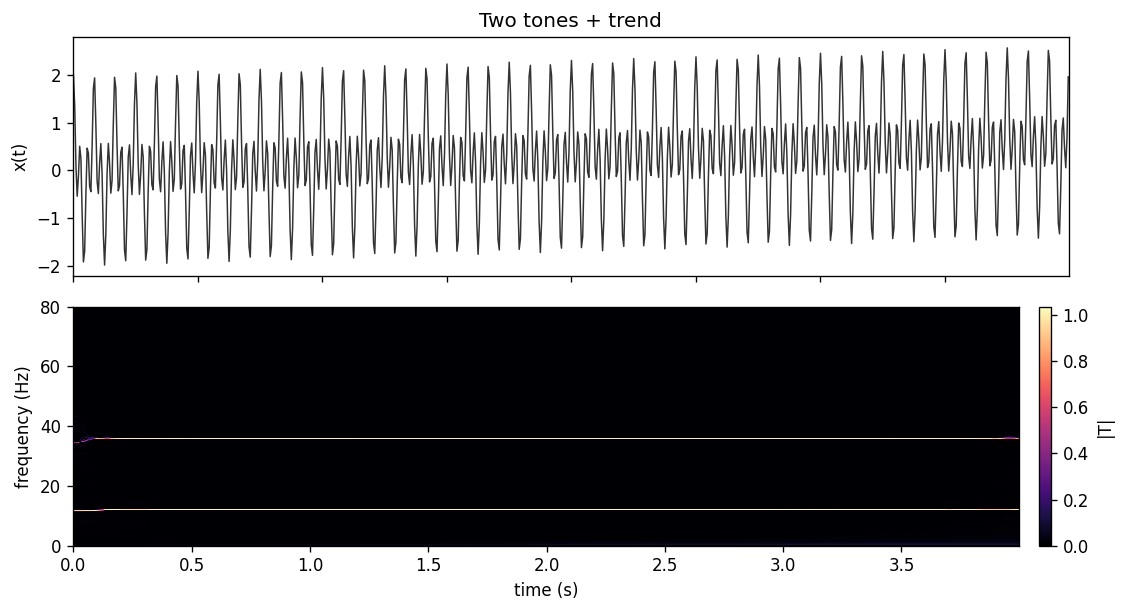

In [2]:
fs = 200.0
t = np.arange(0.0, 4.0, 1.0 / fs)
comp1 = np.cos(2.0 * np.pi * 12.0 * t)
comp2 = np.cos(2.0 * np.pi * 36.0 * t)
trend = 0.15 * t
x = comp1 + comp2 + trend

sst = SST(n_voices=16, n_levels=4, wavelet="bump")
imfs, tfr, freq = sst.fit_transform(x, return_tfr=True)
hz = freq * fs
print("IMFs", imfs.shape, "TFR", tfr.shape, "n_bands+res", imfs.shape[0])
print("prefix recon max |error|", np.max(np.abs(imfs.sum(0) - x)))

fig, axes = plt.subplots(2, 1, figsize=(9.5, 5.2), sharex=True)
axes[0].plot(t, x, color="0.2", lw=0.9)
axes[0].set_ylabel("x(t)")
axes[0].set_title("Two tones + trend")
im = axes[1].pcolormesh(t, hz, np.abs(tfr), shading="auto", cmap="magma")
axes[1].set_ylabel("frequency (Hz)")
axes[1].set_xlabel("time (s)")
axes[1].set_ylim(0, 80)
fig.colorbar(im, ax=axes[1], fraction=0.03, pad=0.02, label="|T|")
fig.tight_layout()
plt.show()

## 3. Modal decomposition versus EMD

`fit_transform` returns one waveform per adaptive tile, plus a residual.
Well-separated tones should land in different tiles. Classical EMD sifts
the same mixture without an explicit frequency grid; SST modes are
*band-limited by construction*.


EMD (4, 800)


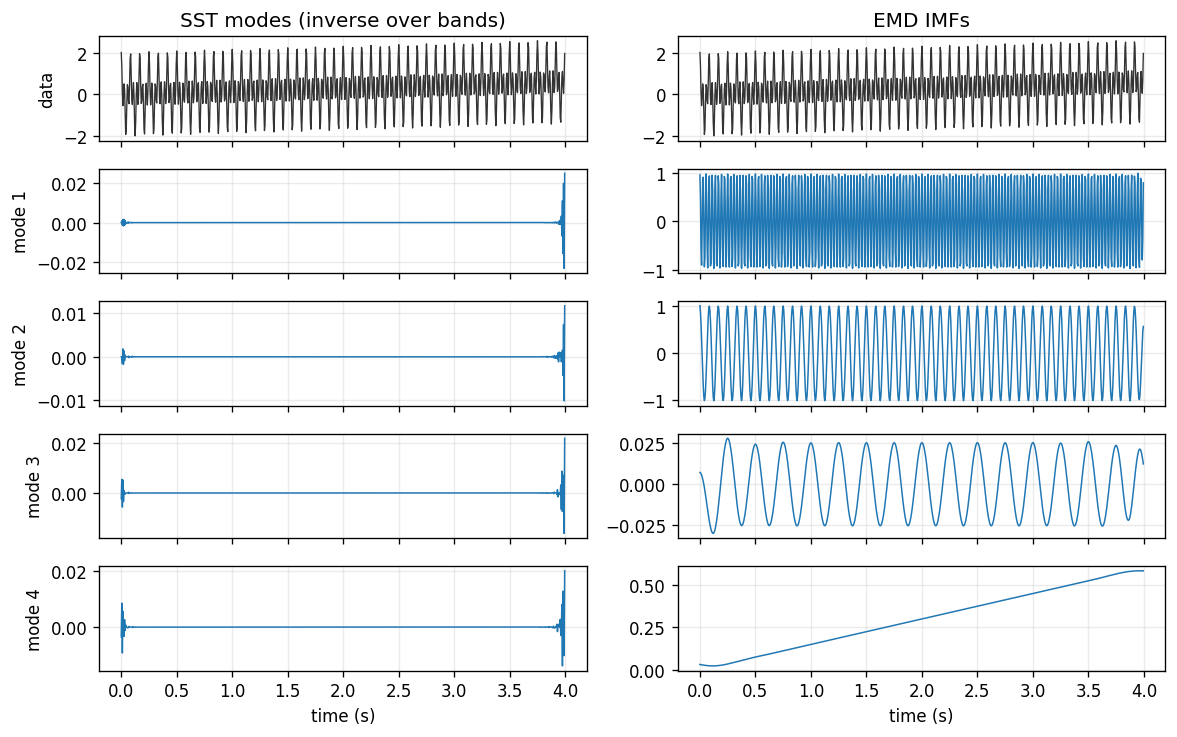

mode energies [2.00000e-03 0.00000e+00 1.00000e-03 1.00000e-03 1.00000e-03 3.00000e-03
 2.30000e-02 4.02178e+02 8.40000e-02 4.06773e+02 1.89080e+01]


In [3]:
emd_imfs = EMD().fit_transform(x)
print("EMD", emd_imfs.shape)

n_show = min(4, imfs.shape[0])
fig, axes = plt.subplots(n_show + 1, 2, figsize=(10, 1.25 * (n_show + 1)), sharex=True)
axes[0, 0].plot(t, x, color="0.2", lw=0.8)
axes[0, 0].set_title("SST modes (inverse over bands)")
axes[0, 0].set_ylabel("data")
axes[0, 1].plot(t, x, color="0.2", lw=0.8)
axes[0, 1].set_title("EMD IMFs")
for k in range(n_show):
    axes[k + 1, 0].plot(t, imfs[k], lw=0.9)
    label = "res." if k == imfs.shape[0] - 1 else f"mode {k + 1}"
    axes[k + 1, 0].set_ylabel(label)
    if k < emd_imfs.shape[0]:
        axes[k + 1, 1].plot(t, emd_imfs[k], lw=0.9)
for ax in axes.ravel():
    ax.grid(True, alpha=0.25)
axes[-1, 0].set_xlabel("time (s)")
axes[-1, 1].set_xlabel("time (s)")
fig.tight_layout()
plt.show()

# energy of SST modes vs ground-truth tones (ignore residual)
truth = [comp2, comp1, trend]
print("mode energies", np.round(np.sum(imfs[:-1] ** 2, axis=1), 3))

## Takeaway

SST **sharpens** a CWT into an IF map and **inverts** selected bands to
AM–FM modes. It is not a sifting decomposer: $K$ is the number of
bandwidth tiles, reconstruction of the full record uses the residual
row, and closely spaced chirps that share a tile cannot be split
(paper Remark 4). For a stream of IMFs with no frequency grid, use EMD;
for readable instantaneous frequency and invertible tiles, use SST.

```python
from pysdkit import SST
imfs = SST(n_voices=32, wavelet="bump")(signal)   # (n_modes, T)
tfr, freq = SST().transform(signal)               # (F, T), cycles/sample
```
